Title: Rsds_dist_comp.ipynb

Purpose: Compare the distribution of RSDS in current and future climate

Author: Onno Nennecke on 02.06.2025 Modified: 12.05.2026

Input data: 

- rsds Data from CMIP
    - These files lie here: /climca/people/onennecke/not_debiased_data/
    - These files lie here: /climca/people/onennecke/not_debiased_data_future/
- Used Runs File: CMIP6_runs_future.csv and CESM2_LE_runs.csv
    - These files lie here: /home/onennecke/CMIP_models/

Output data:

- Some plots to compare

### Load libraries and functions

In [1]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp, wasserstein_distance
import os
import cartopy.feature as cfeature
import cartopy.crs as ccrs

### Define var name

In [2]:
variable_name = 'rsds'

### Read data

In [3]:
# Read the dataframe from the csv file
used_runs_fut = pd.read_csv('/home/onennecke/CMIP_models/CMIP6_runs_future.csv')
used_runs_CESM_LE = pd.read_csv('/home/onennecke/CMIP_models/CESM2_LE_runs.csv')


used_runs = pd.concat([used_runs_fut, used_runs_CESM_LE], ignore_index=True)
# Add one row with ERA5 using pd.concat
era5_row = pd.DataFrame([{
    'ESM': 'ERA5',
    'Institution': 'ECMWF',
    'run': 'hist'
}])
used_runs = pd.concat([used_runs, era5_row], ignore_index=True)
# Change the ref column to 1 for the first instance of each model
# used_runs['Ref'] = used_runs.groupby(['ESM', 'Institution']).cumcount().apply(lambda x: 1 if x == 0 else 0)

ESMs = used_runs['ESM'].unique()

In [4]:
base_path_fut = '/climca/people/onennecke/not_debiased_data_future/'
base_path_cur = '/climca/people/onennecke/not_debiased_data/'

# Build a list of file names from the used_runs dataframe
file_names = []
for index, row in used_runs.iterrows():
    esm = row['ESM']
    # institution = row['Institution']
    run = row['run']
    
    # Construct the file name based on the ESM, institution, and run
    file_name_pattern = f'{esm}_{run}_{variable_name}.nc'
    
    # Append the file name pattern to the list
    file_names.append(file_name_pattern)
# file_names


In [5]:
# Load installed capacity data
grid_offshore = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_ic.nc')
grid_offshore = grid_offshore['wind_off_cap']
mask_offshore = xr.where(np.isfinite(grid_offshore), 1, 0)
grid_onshore = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_onshore_ic.nc')
grid_onshore = grid_onshore['wind_on_cap']
mask_onshore = xr.where(np.isfinite(grid_onshore), 1, 0)
grid_solar = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/solar_ic_netto.nc')
# grid_solar = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/solar_ic.nc')
grid_solar = grid_solar['solar_cap']
mask_solar = xr.where(np.isfinite(grid_solar), 1, 0)
population = xr.open_dataset('/climca/people/onennecke/population_data/population_regrid_weights.nc')
population = population['population']
mask_population = xr.where(np.isfinite(population), 1, 0)
# Overall mask
overall_mask = mask_offshore + mask_onshore + mask_solar + mask_population
overall_mask = xr.where(overall_mask > 0, 1, 0)

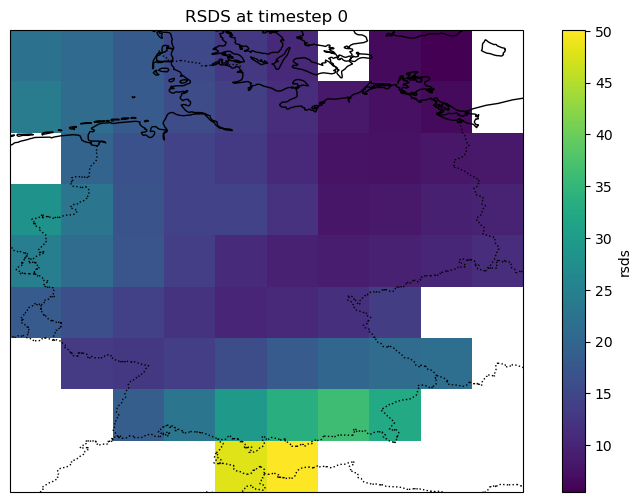

In [6]:
# Open one file to check format
tst = xr.open_dataset(os.path.join(base_path_cur, file_names[0]))
tst.load()

# Create Cartopy axis
fig, ax = plt.subplots(
    figsize=(10, 6),
    subplot_kw={"projection": ccrs.PlateCarree()}
)
# Add map features
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
# Plot data
im = ax.pcolormesh(tst.lon, tst.lat, tst['rsds'].isel(time=0).where(overall_mask == 1),
    transform=ccrs.PlateCarree(),
    shading='auto'
)
plt.colorbar(im, ax=ax, label='rsds')
ax.set_title("RSDS at timestep 0")
plt.show()

In [7]:
ds_list = []
counter = 1
for file_name in file_names:
    file_path = os.path.join(base_path_cur, file_name)
    print(f'{counter}/{len(file_names)}: Processing file: {file_path}')
    if os.path.exists(file_path):
        ds = xr.open_dataset(file_path)
        esm_run = ds.ESM_run.values
        if '_LE2' in str(esm_run):
            esm_run = str(esm_run).replace('_LE2', '')
            ds["ESM"] = "CESM2"
        # Select only 6 winter months (October to March)
        ds = ds.sel(time=ds['time.month'].isin([10, 11, 12, 1, 2, 3]))
        # Mask the data with the overall mask
        ds = ds.where(overall_mask == 1)        
        # Calculate the spatial mean over the dimension
        mean_ds = ds.mean(dim=['lat', 'lon'], keep_attrs=True)
        
        ts_output = mean_ds.expand_dims(ESM_run=[esm_run]).assign_coords(ESM_run=[esm_run])
        ds_list.append(ts_output)
    else:
        print(f'File not found: {file_path}')
    counter += 1
esm_ds_cur = xr.concat(ds_list, dim="ESM_run")

ds_list = []
counter = 1
for file_name in file_names:
    file_path = os.path.join(base_path_fut, file_name)
    print(f'{counter}/{len(file_names)}: Processing file: {file_path}')
    if os.path.exists(file_path):
        ds = xr.open_dataset(file_path)
        esm_run = ds.ESM_run.values
        if '_LE2' in str(esm_run):
            esm_run = str(esm_run).replace('_LE2', '')
            ds["ESM"] = "CESM2"
        # Select only 6 winter months (October to March)
        ds = ds.sel(time=ds['time.month'].isin([10, 11, 12, 1, 2, 3]))
        # Mask the data with the overall mask
        ds = ds.where(overall_mask == 1)        
        # Calculate the spatial mean over the dimension
        mean_ds = ds.mean(dim=['lat', 'lon'], keep_attrs=True)
        # Change to C
        ts_output = mean_ds.expand_dims(ESM_run=[esm_run]).assign_coords(ESM_run=[esm_run])
        ds_list.append(ts_output)
    else:
        print(f'File not found: {file_path}')
    counter += 1
esm_ds_fut = xr.concat(ds_list, dim="ESM_run")

1/193: Processing file: /climca/people/onennecke/not_debiased_data/ACCESS-CM2_r4i1p1f1_rsds.nc
2/193: Processing file: /climca/people/onennecke/not_debiased_data/ACCESS-CM2_r5i1p1f1_rsds.nc
3/193: Processing file: /climca/people/onennecke/not_debiased_data/ACCESS-CM2_r1i1p1f1_rsds.nc
4/193: Processing file: /climca/people/onennecke/not_debiased_data/BCC-CSM2-MR_r1i1p1f1_rsds.nc
5/193: Processing file: /climca/people/onennecke/not_debiased_data/CESM2_r4i1p1f1_rsds.nc
6/193: Processing file: /climca/people/onennecke/not_debiased_data/CESM2_r10i1p1f1_rsds.nc
7/193: Processing file: /climca/people/onennecke/not_debiased_data/CESM2_r11i1p1f1_rsds.nc
8/193: Processing file: /climca/people/onennecke/not_debiased_data/EC-Earth3_r149i1p1f1_rsds.nc
9/193: Processing file: /climca/people/onennecke/not_debiased_data/EC-Earth3_r4i1p1f1_rsds.nc
10/193: Processing file: /climca/people/onennecke/not_debiased_data/EC-Earth3_r148i1p1f1_rsds.nc
11/193: Processing file: /climca/people/onennecke/not_debias

In [8]:
# Save the datasets to NetCDF files
esm_ds_cur.to_netcdf(f'/climca/people/onennecke/model_output/var_means_masked/winter_data_condensed/{variable_name}_sp_mean_mask_ex_ws_cur.nc')
esm_ds_fut.to_netcdf(f'/climca/people/onennecke/model_output/var_means_masked/winter_data_condensed/{variable_name}_sp_mean_mask_ex_ws_fut.nc')

In [8]:
esm_data_cur_dict = {}
esm_data_fut_dict = {}

esm_data_cur_dict['All ESMs'] = esm_ds_cur[variable_name].values.ravel()
esm_data_fut = esm_ds_fut[variable_name].values.ravel()
esm_data_fut = esm_data_fut[~np.isnan(esm_data_fut)]
esm_data_fut_dict['All ESMs'] = esm_data_fut

for esm in np.unique(esm_ds_cur.ESM.values):
    esm_data_cur = esm_ds_cur.where(esm_ds_cur.ESM == esm)[variable_name].values.ravel()
    esm_data_cur = esm_data_cur[~np.isnan(esm_data_cur)]
    esm_data_cur_dict[esm] = esm_data_cur
    esm_data_fut = esm_ds_fut.where(esm_ds_fut.ESM == esm)[variable_name].values.ravel()
    esm_data_fut = esm_data_fut[~np.isnan(esm_data_fut)]
    esm_data_fut_dict[esm] = esm_data_fut
    # break


In [9]:
esm_data_cur_dict.keys()

for key in esm_data_cur_dict.keys():
    print(f'{key}: {len(esm_data_cur_dict[key])} values')
    print(f'{key}: {len(esm_data_cur_dict[key]) / 1820} values')

All ESMs: 351260 values
All ESMs: 193.0 values
ACCESS-CM2: 5460 values
ACCESS-CM2: 3.0 values
BCC-CSM2-MR: 1820 values
BCC-CSM2-MR: 1.0 values
CESM2: 187460 values
CESM2: 103.0 values
EC-Earth3: 98280 values
EC-Earth3: 54.0 values
ERA5: 1820 values
ERA5: 1.0 values
GFDL-ESM4: 1820 values
GFDL-ESM4: 1.0 values
KACE-1-0-G: 5460 values
KACE-1-0-G: 3.0 values
MPI-ESM1-2-HR: 18200 values
MPI-ESM1-2-HR: 10.0 values
MRI-ESM2-0: 9100 values
MRI-ESM2-0: 5.0 values
TaiESM1: 1820 values
TaiESM1: 1.0 values
UKESM1-0-LL: 20020 values
UKESM1-0-LL: 11.0 values


In [10]:
all_keys = list(esm_data_cur_dict.keys())

n = len(all_keys)


In [11]:
import numpy as np
import pandas as pd
from scipy.stats import ks_2samp

rows = []

for esm in all_keys:
    cur = esm_data_cur_dict[esm]
    fut = esm_data_fut_dict[esm]

    ks_stat, ks_p = ks_2samp(cur, fut)

    rows.append({
        'ESM': esm,
        'Current Mean': np.mean(cur),
        'Future Mean': np.mean(fut),
        'Delta Mean': np.mean(fut) - np.mean(cur),
        'Delta Mean (%)': (np.mean(fut) - np.mean(cur)) / np.mean(cur) * 100,
        'Current Std': np.std(cur),
        'Future Std': np.std(fut),
        'Delta Std': np.std(fut) - np.std(cur),
        'Delta Std (%)': (np.std(fut) - np.std(cur)) / np.std(cur) * 100,
        'KS Statistic': ks_stat,
        'KS p-value': ks_p,
        # 'Wasserstein': wasserstein_distance(cur, fut),
    })

# Convert to DataFrame for easy mean calculation
df = pd.DataFrame(rows)

# Filter out any existing 'All' or 'All_weighted' rows before calculating the weighted average
df_esm_only = df[~df['ESM'].isin(['All ESMs', 'All_weighted'])]

# Append the All_weighted row (only using ESM data)
# rows.append({
#     'ESM': 'All (weighted)',
#     'Current Mean': df_esm_only['Current Mean'].mean(),
#     'Future Mean': df_esm_only['Future Mean'].mean(),
#     'Delta Mean': df_esm_only['Future Mean'].mean() - df_esm_only['Current Mean'].mean(),
#     'Delta Mean (%)': (df_esm_only['Future Mean'].mean() - df_esm_only['Current Mean'].mean()) / df_esm_only['Current Mean'].mean() * 100,
#     'Current Std': df_esm_only['Current Std'].mean(),
#     'Future Std': df_esm_only['Future Std'].mean(),
#     'Delta Std': df_esm_only['Future Std'].mean() - df_esm_only['Current Std'].mean(),
#     'Delta Std (%)': (df_esm_only['Future Std'].mean() - df_esm_only['Current Std'].mean()) / df_esm_only['Current Std'].mean() * 100,
#     'KS Statistic': df_esm_only['KS Statistic'].mean(),
#     'KS p-value': df_esm_only['KS p-value'].mean(),
#     # 'Wasserstein': df_esm_only['Wasserstein'].mean(),
# })
summary_df = pd.DataFrame(rows)

# Change position of the All (weighted) row to the top
summary_df = pd.concat([summary_df[summary_df['ESM'] == 'All (weighted)'], summary_df[summary_df['ESM'] != 'All (weighted)']], ignore_index=True)

# Change the position of ERA5 to the top of the dataframe
summary_df = pd.concat([summary_df[summary_df['ESM'] == 'ERA5'], summary_df[summary_df['ESM'] != 'ERA5']], ignore_index=True)


print(summary_df)


              ESM  Current Mean  Future Mean  Delta Mean  Delta Mean (%)  \
0            ERA5     59.991802          NaN         NaN             NaN   
1        All ESMs     59.937614    60.038364    0.100750        0.168091   
2      ACCESS-CM2     53.642239    54.611099    0.968861        1.806152   
3     BCC-CSM2-MR     47.889801    48.132973    0.243172        0.507773   
4           CESM2     60.037201    60.343315    0.306114        0.509874   
5       EC-Earth3     61.604763    61.046139   -0.558624       -0.906787   
6       GFDL-ESM4     54.001675    54.662041    0.660366        1.222862   
7      KACE-1-0-G     57.115280    58.101593    0.986313        1.726881   
8   MPI-ESM1-2-HR     51.144432    51.218811    0.074379        0.145429   
9      MRI-ESM2-0     63.438206    64.457695    1.019489        1.607059   
10        TaiESM1     58.571175    59.960835    1.389660        2.372600   
11    UKESM1-0-LL     61.464340    61.831177    0.366837        0.596828   

    Current

/tmp/ipykernel_1905668/1968699567.py:11: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  ks_stat, ks_p = ks_2samp(cur, fut)
/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/numpy/_core/_methods.py:227: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/numpy/_core/_methods.py:184: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmea

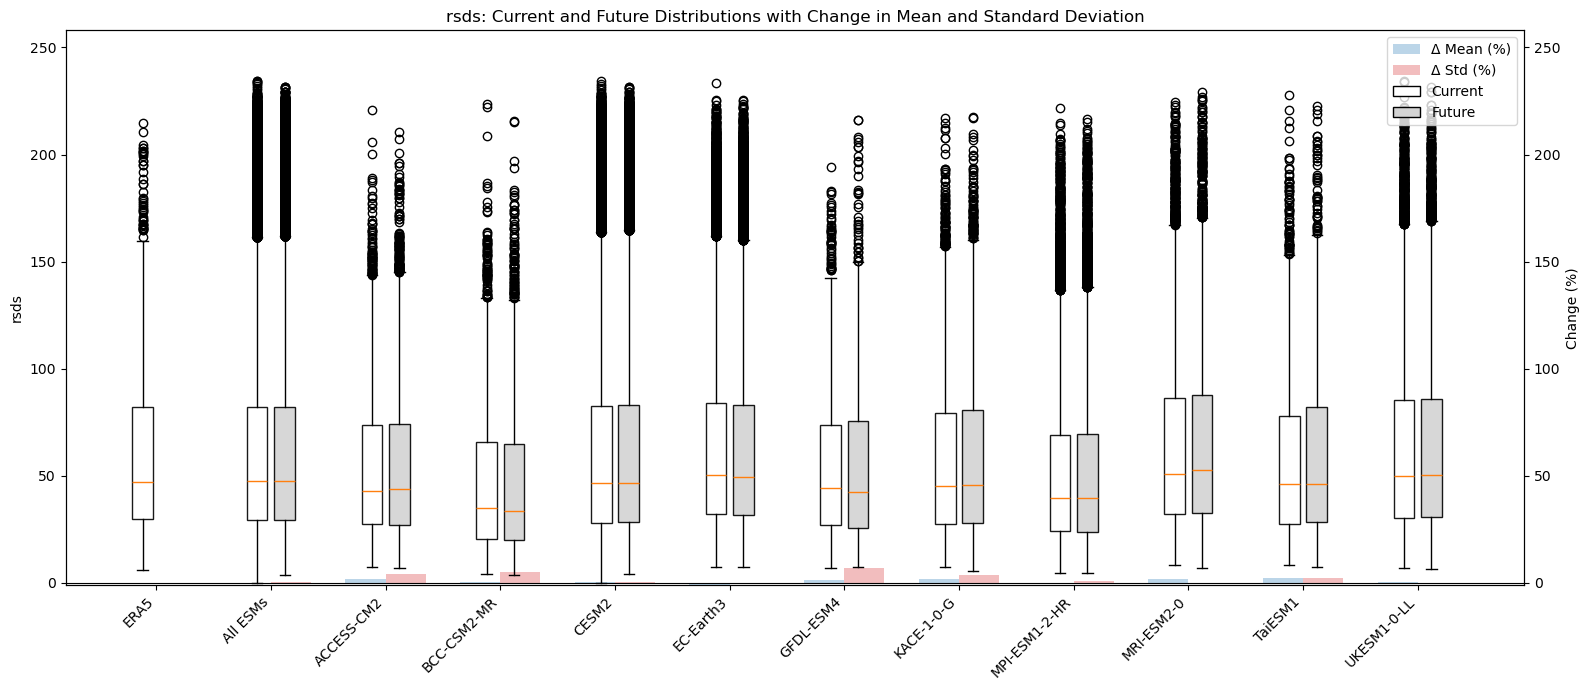

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --------------------------------------------------
# Data
# --------------------------------------------------
esms = summary_df['ESM'].values
delta_mean = summary_df['Delta Mean (%)'].values
delta_std = summary_df['Delta Std (%)'].values

n = len(esms)
x = np.arange(n)

current_data = [esm_data_cur_dict[k] for k in esms]
future_data = [esm_data_fut_dict[k] for k in esms]

# --------------------------------------------------
# Figure and axes
# Left axis  -> boxplots (actual variable values)
# Right axis -> percent changes (bars)
# --------------------------------------------------
fig, ax_box = plt.subplots(figsize=(16, 7))
ax_bar = ax_box.twinx()

# --------------------------------------------------
# Background bars (Δ Mean and Δ Std)
# --------------------------------------------------
bar_width = 0.35

ax_bar.bar(
    x - bar_width / 2,
    delta_mean,
    width=bar_width,
    color='tab:blue',
    alpha=0.30,
    label='Δ Mean (%)',
    zorder=1
)

ax_bar.bar(
    x + bar_width / 2,
    delta_std,
    width=bar_width,
    color='tab:red',
    alpha=0.30,
    label='Δ Std (%)',
    zorder=1
)

# --------------------------------------------------
# Boxplots on top
# --------------------------------------------------
offset = 0.12

current_pos = x - offset
future_pos = x + offset

bp1 = ax_box.boxplot(
    current_data,
    positions=current_pos,
    widths=0.18,
    patch_artist=True,
    manage_ticks=False,
    showfliers=True,
    zorder=3
)

bp2 = ax_box.boxplot(
    future_data,
    positions=future_pos,
    widths=0.18,
    patch_artist=True,
    manage_ticks=False,
    showfliers=True,
    zorder=3
)

# --------------------------------------------------
# Styling boxplots
# --------------------------------------------------
for box in bp1['boxes']:
    box.set(facecolor='white', edgecolor='black', alpha=0.9)

for box in bp2['boxes']:
    box.set(facecolor='lightgray', edgecolor='black', alpha=0.9)

# --------------------------------------------------
# Align zero lines on both axes
# --------------------------------------------------

# Boxplot axis limits from data
all_box_values = np.concatenate([
    np.concatenate(current_data),
    np.concatenate(future_data)
])

# box_abs = np.nanmax(np.abs(all_box_values))
# ax_box.set_ylim(-1.1 * box_abs, 1.1 * box_abs)

# # Bar axis limits from percentage changes
# bar_abs = max(
#     np.nanmax(np.abs(delta_mean)),
#     np.nanmax(np.abs(delta_std))
# )

# ax_bar.set_ylim(-1.1 * bar_abs, 1.1 * bar_abs)


box_bar_max = np.nanmax(np.concatenate([np.abs(all_box_values), np.abs(delta_mean), np.abs(delta_std)]))
box_bar_min = np.nanmin(np.concatenate([all_box_values, delta_mean, delta_std]))
ax_box.set_ylim(1.1 * box_bar_min, 1.1 * box_bar_max)
ax_bar.set_ylim(1.1 * box_bar_min, 1.1 * box_bar_max)

# Shared zero line
ax_box.axhline(0, color='black', linewidth=0.8, zorder=2)

# --------------------------------------------------
# Labels
# --------------------------------------------------
ax_box.set_ylabel(variable_name)
ax_bar.set_ylabel('Change (%)')

ax_box.set_xticks(x)
ax_box.set_xticklabels(esms, rotation=45, ha='right')

# --------------------------------------------------
# Put boxplots visually above bars
# --------------------------------------------------
ax_box.set_zorder(2)
ax_bar.set_zorder(1)

ax_box.patch.set_alpha(0)

# --------------------------------------------------
# Legend
# --------------------------------------------------
legend_elements = [
    Patch(facecolor='tab:blue', alpha=0.30, label='Δ Mean (%)'),
    Patch(facecolor='tab:red', alpha=0.30, label='Δ Std (%)'),
    Patch(facecolor='white', edgecolor='black', label='Current'),
    Patch(facecolor='lightgray', edgecolor='black', label='Future')
]

ax_box.legend(handles=legend_elements, loc='upper right')

# --------------------------------------------------
# Title
# --------------------------------------------------
plt.title(
    f'{variable_name}: Current and Future Distributions with '
    'Change in Mean and Standard Deviation'
)

plt.tight_layout()
plt.show()

In [ ]:
# Save the summary DataFrame to a CSV file
summary_df.to_csv('/home/onennecke/CMIP_models/rsds_summary_statistics.csv', index=False)

In [9]:


rows = []

for esm in all_keys:

    cur = esm_data_cur_dict[esm]
    fut = esm_data_fut_dict[esm]

    ks_stat, ks_p = ks_2samp(cur, fut)

    rows.append({
        'ESM': esm,
        'Current Mean': np.mean(cur),
        'Future Mean': np.mean(fut),
        'Delta Mean': np.mean(fut) - np.mean(cur),
        'Delta Mean (%)': (np.mean(fut) - np.mean(cur)) / np.mean(cur) * 100,
        'Current Std': np.std(cur),
        'Future Std': np.std(fut),
        'Delta Std': np.std(fut) - np.std(cur),
        'Delta Std (%)': (np.std(fut) - np.std(cur)) / np.std(cur) * 100,
        'KS Statistic': ks_stat,
        'KS p-value': ks_p,
        # 'Wasserstein': wasserstein_distance(cur, fut),
    })

summary_df = pd.DataFrame(rows)

print(summary_df)

              ESM  Current Mean  Future Mean  Delta Mean  Delta Mean (%)  \
0             All     59.937328    60.038364    0.101036        0.168570   
1      ACCESS-CM2     53.642239    54.611099    0.968861        1.806152   
2     BCC-CSM2-MR     47.889801    48.132973    0.243172        0.507773   
3           CESM2     60.249088    61.075138    0.826050        1.371058   
4        CESM2_LE     60.030846    60.321350    0.290504        0.483925   
5       EC-Earth3     61.604763    61.046139   -0.558624       -0.906787   
6       GFDL-ESM4     54.001675    54.662041    0.660366        1.222862   
7      KACE-1-0-G     57.115280    58.101593    0.986313        1.726881   
8   MPI-ESM1-2-HR     51.144432    51.218811    0.074379        0.145429   
9      MRI-ESM2-0     63.438206    64.457695    1.019489        1.607059   
10        TaiESM1     58.571175    59.960835    1.389660        2.372600   
11    UKESM1-0-LL     61.464340    61.831177    0.366837        0.596828   

    Current

/tmp/ipykernel_784424/2986788715.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(esms, rotation=45)


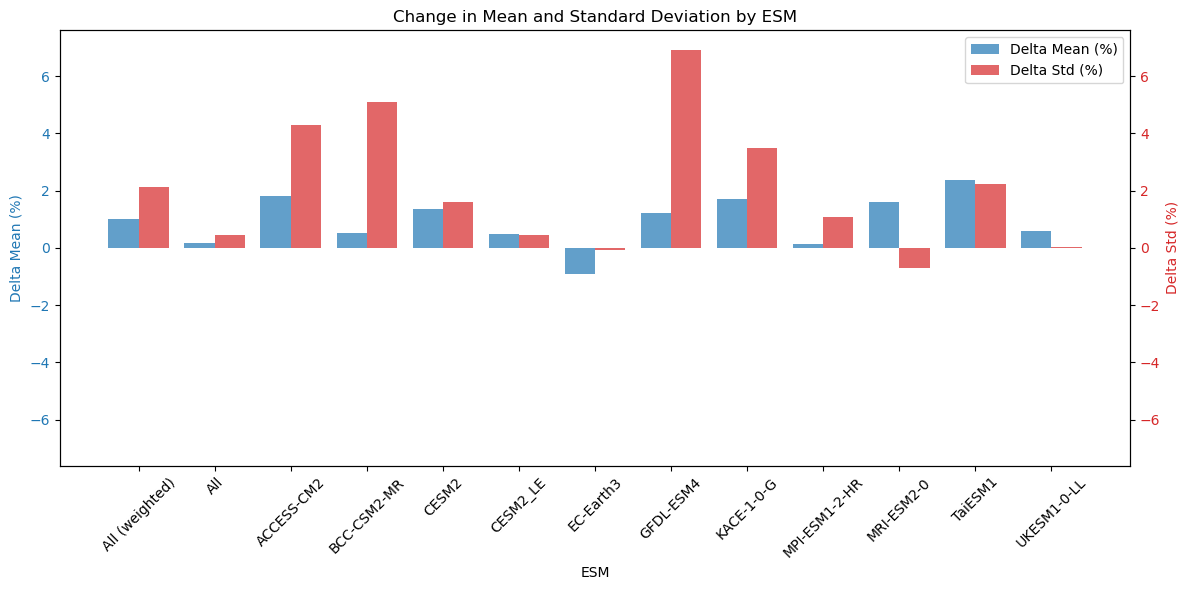

In [15]:
# Assuming summary_df is already created
# Extract data
esms = summary_df['ESM']
delta_mean = summary_df['Delta Mean (%)']
delta_std = summary_df['Delta Std (%)']

max_pos = max(max(delta_mean), max(delta_std))
min_neg = min(min(delta_mean), min(delta_std))
y_limit = max(abs(max_pos), abs(min_neg)) * 1.1

# Create figure and primary axis
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Delta Mean (%) on primary axis
color_mean = 'tab:blue'
ax1.set_xlabel('ESM')
ax1.set_ylabel('Delta Mean (%)', color=color_mean)
ax1.set_ylim(-y_limit, y_limit)
bars_mean = ax1.bar(esms, delta_mean, color=color_mean, width=-0.4, align='edge', alpha=0.7, label='Delta Mean (%)')
ax1.tick_params(axis='y', labelcolor=color_mean)

# Create secondary axis for Delta Std (%)
ax2 = ax1.twinx()
color_std = 'tab:red'
ax2.set_ylabel('Delta Std (%)', color=color_std)
ax2.set_ylim(-y_limit, y_limit)
bars_std = ax2.bar(esms, delta_std, color=color_std, width=0.4,alpha=0.7, align='edge', label='Delta Std (%)')
ax2.tick_params(axis='y', labelcolor=color_std)

# Add legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

# Add title
plt.title('Change in Mean and Standard Deviation by ESM')

# Rotate x-axis labels for readability
ax1.set_xticklabels(esms, rotation=45)


# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

## Huge plots

/tmp/ipykernel_464910/3167560684.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(['Current', 'Future'])
/tmp/ipykernel_464910/3167560684.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(['Current', 'Future'])
/tmp/ipykernel_464910/3167560684.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(['Current', 'Future'])
/tmp/ipykernel_464910/3167560684.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(['Current', 'Future'])
/tmp/ipykernel_464910/3167560684.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or us

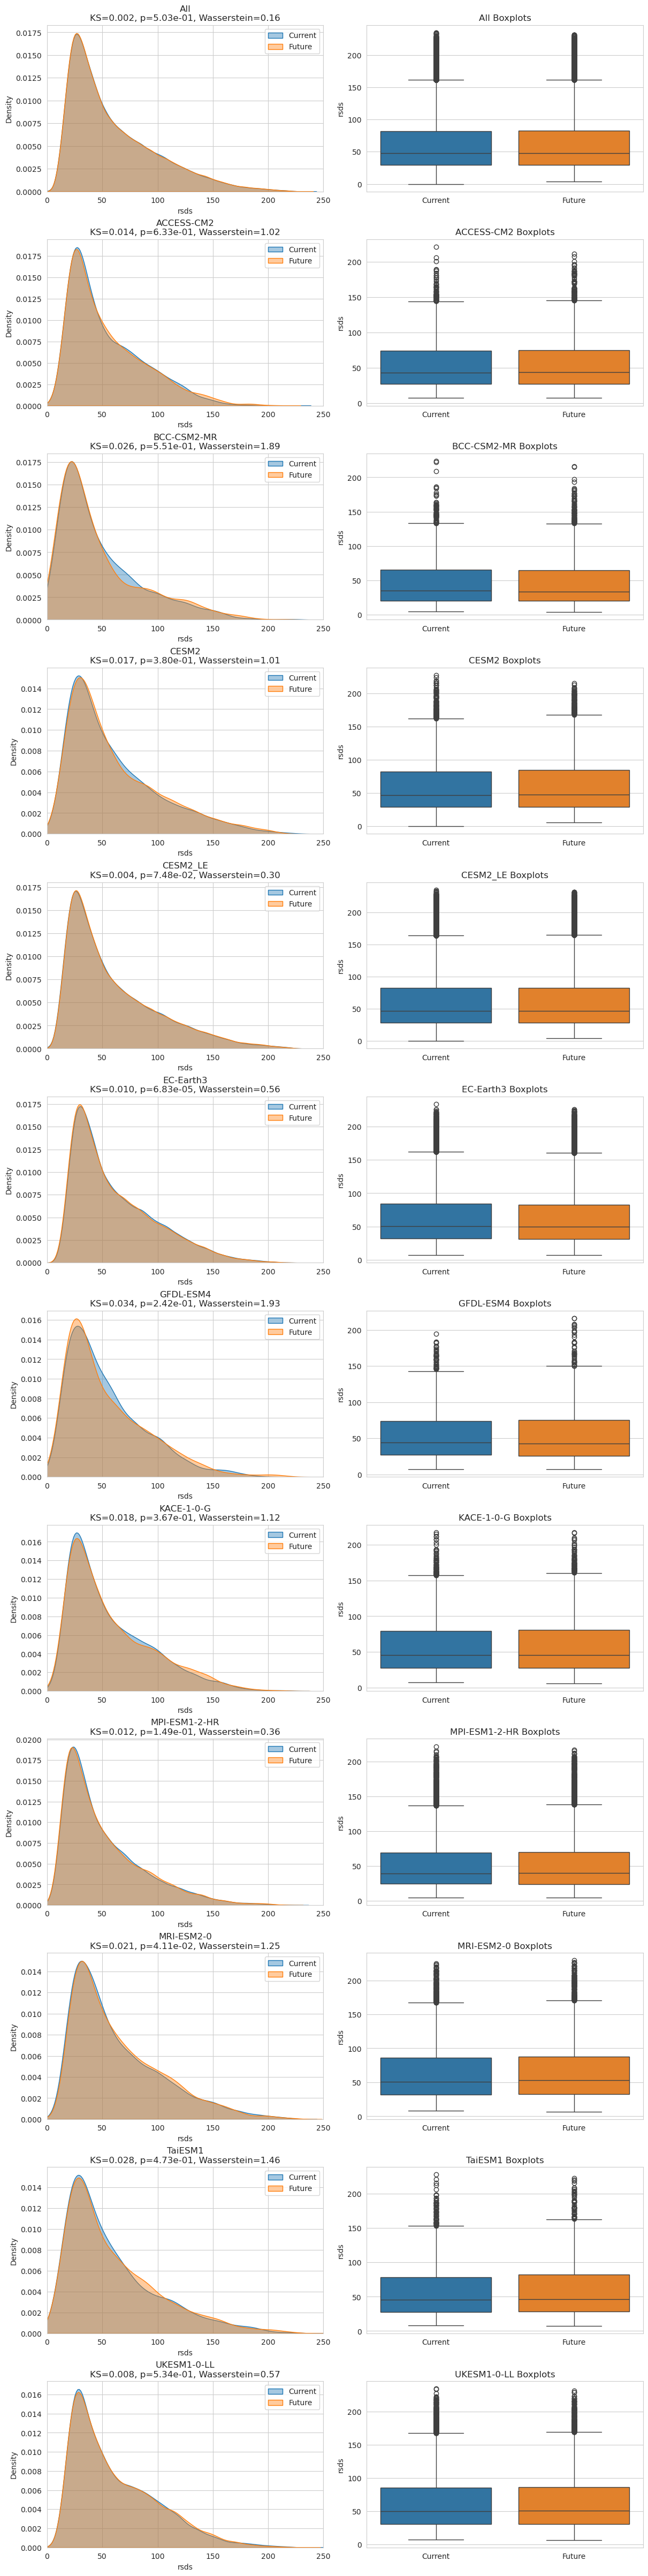

In [ ]:

sns.set_style("whitegrid")


fig, axes = plt.subplots(
    nrows=n,
    ncols=2,
    figsize=(12, 4 * n),
    constrained_layout=True
)

# handle case n=1
if n == 1:
    axes = np.array([axes])

for i, esm in enumerate(all_keys):

    cur = esm_data_cur_dict[esm]
    fut = esm_data_fut_dict[esm]

    # -------------------------
    # KDE plot
    # -------------------------
    ax = axes[i, 0]

    sns.kdeplot(cur, ax=ax, label='Current', fill=True, alpha=0.4)
    sns.kdeplot(fut, ax=ax, label='Future', fill=True, alpha=0.4)
    ax.set_xlim(0, 250)
    # metrics
    ks_stat, ks_p = ks_2samp(cur, fut)
    wass = wasserstein_distance(cur, fut)

    ax.set_title(
        f"{esm}\nKS={ks_stat:.3f}, p={ks_p:.2e}, Wasserstein={wass:.2f}"
    )
    ax.set_xlabel("rsds")
    ax.legend()

    # -------------------------
    # Boxplot
    # -------------------------
    ax2 = axes[i, 1]

    sns.boxplot(
        data=[cur, fut],
        ax=ax2
    )

    ax2.set_xticklabels(['Current', 'Future'])
    ax2.set_title(f"{esm} Boxplots")
    ax2.set_ylabel("rsds")

plt.show()

/tmp/ipykernel_464910/1717194014.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Current', 'Future'])
/tmp/ipykernel_464910/1717194014.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Current', 'Future'])
/tmp/ipykernel_464910/1717194014.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Current', 'Future'])
/tmp/ipykernel_464910/1717194014.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Current', 'Future'])
/tmp/ipykernel_464910/1717194014.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using 

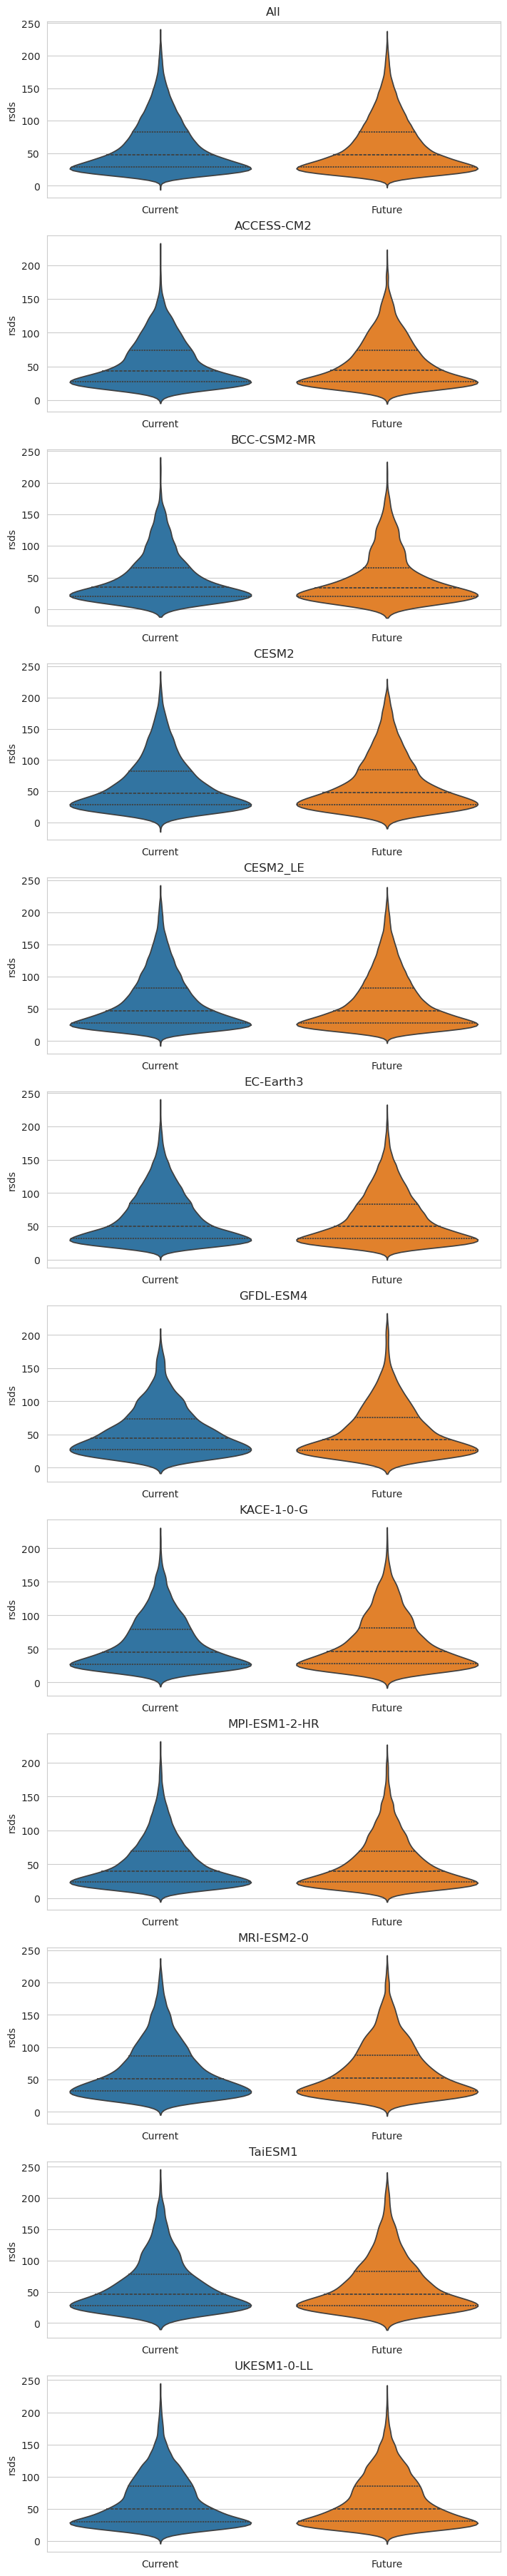

In [ ]:
fig, axes = plt.subplots(
    nrows=len(all_keys),
    figsize=(7, 3 * len(all_keys)),
    constrained_layout=True
)

if len(all_keys) == 1:
    axes = [axes]

for ax, esm in zip(axes, all_keys):

    cur = esm_data_cur_dict[esm]
    fut = esm_data_fut_dict[esm]

    sns.violinplot(
        data=[cur, fut],
        ax=ax,
        inner='quartile'
    )

    ax.set_xticklabels(['Current', 'Future'])
    ax.set_title(esm)
    ax.set_ylabel("rsds")

plt.show()

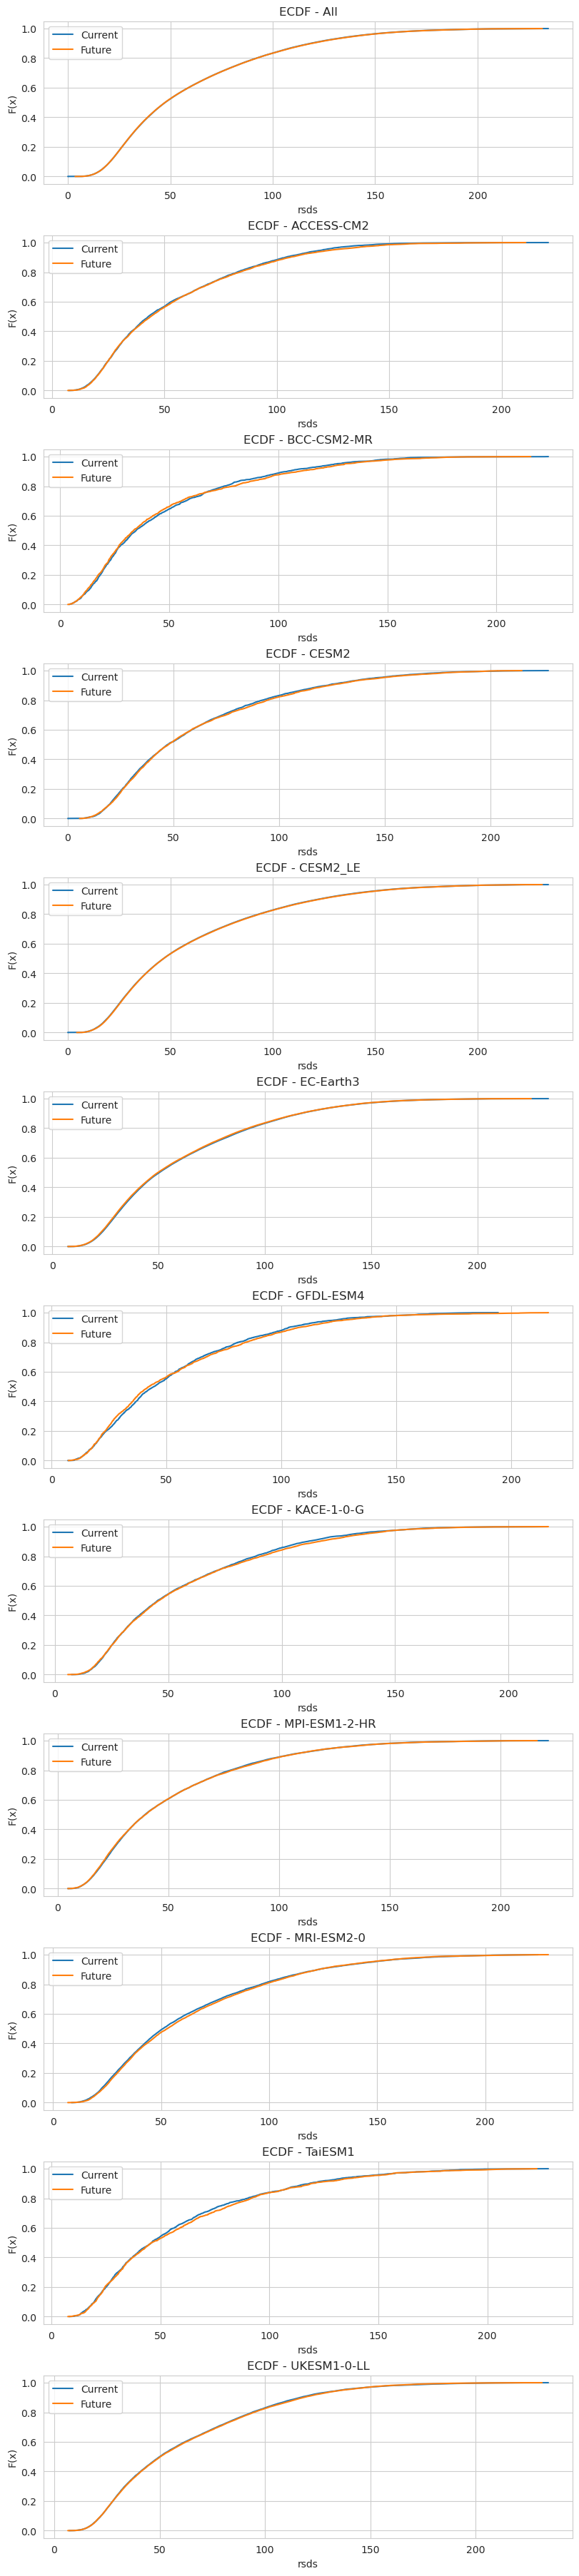

In [ ]:
fig, axes = plt.subplots(
    nrows=len(all_keys),
    figsize=(8, 3 * len(all_keys)),
    constrained_layout=True
)

if len(all_keys) == 1:
    axes = [axes]

for ax, esm in zip(axes, all_keys):

    cur = np.sort(esm_data_cur_dict[esm])
    fut = np.sort(esm_data_fut_dict[esm])

    ecdf_cur = np.arange(1, len(cur)+1) / len(cur)
    ecdf_fut = np.arange(1, len(fut)+1) / len(fut)

    ax.plot(cur, ecdf_cur, label='Current')
    ax.plot(fut, ecdf_fut, label='Future')

    ax.set_title(f"ECDF - {esm}")
    ax.set_xlabel("rsds")
    ax.set_ylabel("F(x)")
    ax.legend()

plt.show()

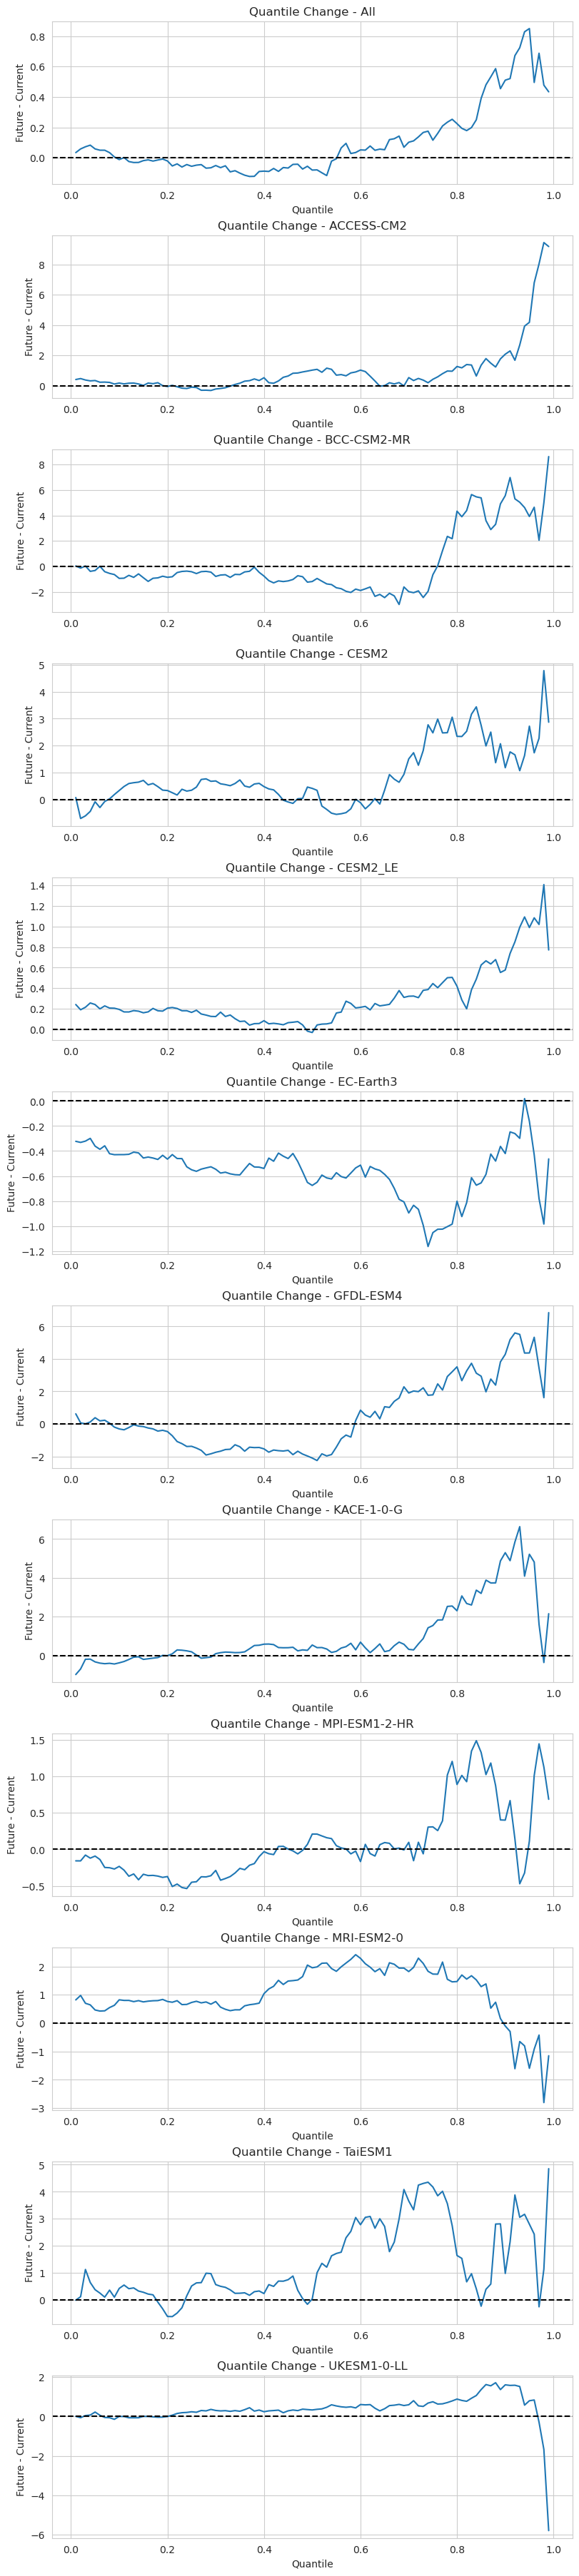

In [ ]:
quantiles = np.linspace(0.01, 0.99, 99)

fig, axes = plt.subplots(
    nrows=len(all_keys),
    figsize=(8, 3 * len(all_keys)),
    constrained_layout=True
)

if len(all_keys) == 1:
    axes = [axes]

for ax, esm in zip(axes, all_keys):

    cur_q = np.quantile(esm_data_cur_dict[esm], quantiles)
    fut_q = np.quantile(esm_data_fut_dict[esm], quantiles)

    delta = fut_q - cur_q

    ax.plot(quantiles, delta)

    ax.axhline(0, color='black', linestyle='--')

    ax.set_title(f"Quantile Change - {esm}")
    ax.set_xlabel("Quantile")
    ax.set_ylabel("Future - Current")

plt.show()